# Open Food Facts — from exploratory analysis to an auditable data-quality pipeline

**Recruiter path · 8–10 minutes.** This notebook connects the original 2022 study
(320,772 products and 162 variables) to its current software-engineering redesign.
The full historical notebooks remain available in `notebooks/historical/`.

## Business question

Can an open, sparse and contributor-maintained food database be transformed into a
defensible analytical dataset without hiding the impact of cleaning decisions?

The answer requires four distinct quality dimensions: **completeness, validity,
uniqueness and consistency**. A row is never removed silently; every rejection is
reported with a stable business reason.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from off_quality import (
    ColumnImputer,
    DataProfiler,
    ImputationMethod,
    QualityPipeline,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE = ROOT / "data" / "sample" / "products.csv"

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\anton\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


## 1. Scale and decisions evidenced by the historical run

These figures come from the preserved executed notebooks. They are not recomputed
from the small deterministic fixture used later for CI.

In [2]:
historical_funnel = pd.DataFrame(
    {
        "stage": ["source snapshot", "decision-relevant variables", "French subset"],
        "rows": [320_772, 320_772, 98_468],
        "columns": [162, 36, 36],
    }
)
historical_funnel

,stage,rows,columns
0,source snapshot,320772,162
1,decision-relevant variables,320772,36
2,French subset,98468,36


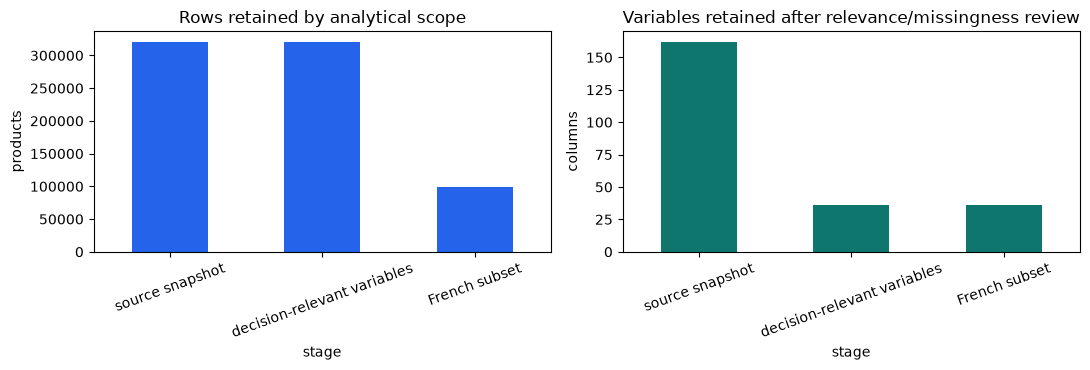

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
historical_funnel.plot.bar(x="stage", y="rows", legend=False, ax=axes[0], color="#2563eb")
historical_funnel.plot.bar(x="stage", y="columns", legend=False, ax=axes[1], color="#0f766e")
axes[0].set(title="Rows retained by analytical scope", ylabel="products")
axes[1].set(title="Variables retained after relevance/missingness review", ylabel="columns")
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()

The reduction from 162 to 36 variables is a **feature-governance decision**, not a
claim that sparse columns are intrinsically useless. Thresholds alter the represented
population and therefore belong in a validated policy object and in the audit report.

## 2. Deterministic executable contract

The repository does not redistribute the full dataset. This versioned fixture contains
duplicates, invalid identifiers, missing values and an implausible numeric value. It
tests behaviour; it is **not** used to manufacture portfolio findings.

In [4]:
raw = pd.read_csv(SAMPLE, dtype={"code": "string"})
raw

,code,product_name,categories,nutrition_grade_fr,energy_100g,sugars_100g,fat_100g,comment
0,3017620422003,Hazelnut spread,spreads,d,2252.0,56.3,30.9,complete row
1,3017620422003,Hazelnut spread duplicate,spreads,d,2252.0,56.3,30.9,duplicate barcode
2,3274080005003,Spring water,waters,a,0.0,0.0,0.0,complete row
3,5449000000996,Cola,beverages,e,180.0,10.6,0.0,complete row
4,3560070977066,Plain yogurt,dairy,b,250.0,4.5,3.2,complete row
5,7622210449283,Chocolate biscuits,snacks,e,2050.0,34.0,24.0,complete row
6,invalid,Invalid barcode product,snacks,c,900.0,12.0,8.0,invalid barcode
7,12345678,Incomplete cereal,cereals,b,NaN,8.2,2.1,missing energy
8,87654321,Incomplete soup,soups,c,220.0,NaN,1.3,missing sugars
9,11223344,Unknown nutrition grade,prepared meals,NaN,630.0,3.5,6.8,missing grade


In [5]:
before = DataProfiler().profile(raw)
pd.DataFrame(
    {
        "dimension": [metric.dimension.value for metric in before.scorecard],
        "score": [metric.score for metric in before.scorecard],
        "evidence": [f"{metric.numerator}/{metric.denominator}" for metric in before.scorecard],
    }
)

,dimension,score,evidence
0,completeness,0.958333,92/96
1,uniqueness,0.916667,11/12


## 3. Composable cleaning strategies

`QualityPipeline` depends on a `FrameRule` protocol. Normalisation, sparse-column
selection, barcode validation and deduplication are independent strategies. New domain
rules can therefore be added without modifying the orchestrator (Open/Closed and
Dependency Inversion principles).

In [6]:
clean, report = QualityPipeline().run(raw)
report

CleaningReport(input_rows=12, output_rows=10, input_columns=8, output_columns=8, rejected_by_reason=mappingproxy({<RejectionReason.INVALID_BARCODE: 'invalid_barcode'>: 1, <RejectionReason.DUPLICATE_BARCODE: 'duplicate_barcode'>: 1}))

In [7]:
pd.DataFrame(
    {
        "reason": [reason.value for reason in report.rejected_by_reason],
        "rows": list(report.rejected_by_reason.values()),
    }
)

,reason,rows
0,invalid_barcode,1
1,duplicate_barcode,1


The intentionally implausible energy value remains visible: format validation and
domain plausibility are separate concerns. Automatically deleting it would conceal a
business decision that needs domain agreement.

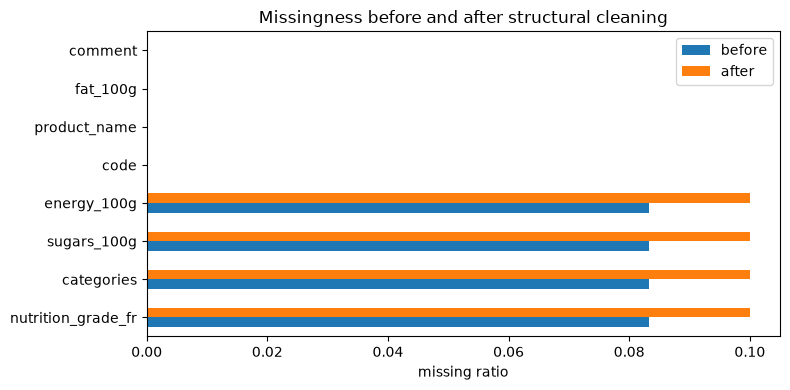

In [8]:
missing = pd.DataFrame(
    {
        "before": raw.isna().mean(),
        "after": clean.isna().mean(),
    }
).sort_values("before", ascending=False)
missing.head(8).plot.barh(figsize=(8, 4), title="Missingness before and after structural cleaning")
plt.xlabel("missing ratio")
plt.tight_layout()

## 4. Leakage-aware imputation

Imputation is fitted on a training partition and only then applied to unseen rows.
The held-out value cannot influence the learned median. This corrects a common weakness
of exploratory notebooks while preserving the original investigation of imputation.

In [9]:
training = clean.iloc[:-2].copy()
holdout = clean.iloc[-2:].copy()
imputer = ColumnImputer(("energy_100g", "sugars_100g"), ImputationMethod.MEDIAN)
fitted = imputer.fit(training)
comparison = holdout[["code", "energy_100g", "sugars_100g"]].copy()
transformed = fitted.transform(holdout)
comparison[["energy_imputed", "sugars_imputed"]] = transformed[["energy_100g", "sugars_100g"]]
comparison

,code,energy_100g,sugars_100g,energy_imputed,sugars_imputed
8,44332211,99999.0,5.0,99999.0,5.0
9,99887766,450.0,7.0,450.0,7.0


## 5. What this proves — and what it does not

**Demonstrated:** wide-table profiling, qualitative and quantitative auditing,
categorical exploration, missing-data reasoning, iterative experimentation, PCA,
interactive visualisation, and a modern typed implementation with immutable reports,
strategies, streaming support and tests.

**Not claimed:** medical validity, causal nutritional conclusions, or generalisation
from the CI fixture. Historical outputs describe a dated snapshot; current Open Food
Facts data may differ.

## Deep-dive map

- `historical/P3_01_notebook.ipynb` — full end-to-end study;
- `historical/p3_quant.ipynb` — quantitative profiling, outliers, correlations and PCA;
- `historical/p3_qual.ipynb` — categorical semantics and text exploration;
- `historical/P3_01_plotly.ipynb` — interactive visual experiments;
- `historical/P3_01_voila.ipynb` — dashboard delivery experiment;
- `src/off_quality/` — maintained typed implementation;
- `tests/` — executable behavioural evidence.